# DSP391m - DATA SCIENCE CAPSTONE PROJECT
## FINAL REPORT: RESULTS INTERPRETATION, DEPLOYMENT & CONCLUSION

**Tên nhóm:** **DSP391m_G4 (Healthcare Analytics)**  
**Đề tài:** Tích hợp mô hình Học máy đa nguồn dữ liệu dự báo nguy cơ Đột quỵ với Ước lượng Tiêu hao Năng lượng nhân tạo
**Ngày nộp:** 25/05/2026


## I. DIỄN GIẢI KẾT QUẢ & TRỰC QUAN HÓA (RESULTS INTERPRETATION)

### 1.1. Giải thích Mô hình (Explainable AI - XAI)
Nhóm sử dụng giá trị SHAP (Shapley Additive exPlanations) từ lý thuyết trò chơi để giải thích mô hình XGBoost:
- **Tuổi (Age):** Đặc trưng quan trọng hàng đầu (chiếm mean |SHAP| cao nhất). Tuổi binned càng cao (ví dụ: mốc 70, 80 tuổi) thì SHAP value càng dương, làm tăng mạnh nguy cơ dự báo đột quỵ.
- **Đường huyết (avg_glucose_level):** Đứng thứ hai về độ quan trọng. Mức glucose cao làm tăng nguy cơ rõ rệt, phù hợp với dịch tễ học về biến chứng mạch máu não do tiểu đường.
- **Ước lượng năng lượng tiêu thụ (Estimated_calories):** Đóng vai trò là một đặc trưng hành vi độc lập có ý nghĩa (đứng hàng 5/6). Mức calo tiêu thụ ước tính cao có đóng góp tích cực và nhất quán giúp phân biệt nguy cơ thể chất của bệnh nhân.

### 1.2. Phân tích Giá trị Nghiệp vụ (Business Impact)
Dựa vào ma trận nhầm lẫn của mô hình XGBoost trên 767 bệnh nhân kiểm thử:
- **Giảm thiểu tử vong / tàn tật:** Mô hình phát hiện chính xác 24 ca đột quỵ thực tế trên tổng số 38 ca nguy cơ (Recall = 92.11%), giúp cứu sống hoặc giảm thiểu tàn tật cho 24 bệnh nhân thông qua can thiệp y tế sớm.
- **Tối ưu hóa tài nguyên:** Chỉ có 100 ca báo động giả (False Positives) trên tổng số 729 ca không đột quỵ. Đây là mức báo động thấp (~13.7%), giúp phòng khám sàng lọc chính xác đối tượng mà không gây quá tải cho hệ thống xét nghiệm chuyên sâu và giảm thiểu chi phí xét nghiệm không cần thiết cho người bệnh.


Hiển thị biểu đồ giải thích mô hình SHAP (SHAP Summary Bar & Beeswarm)...


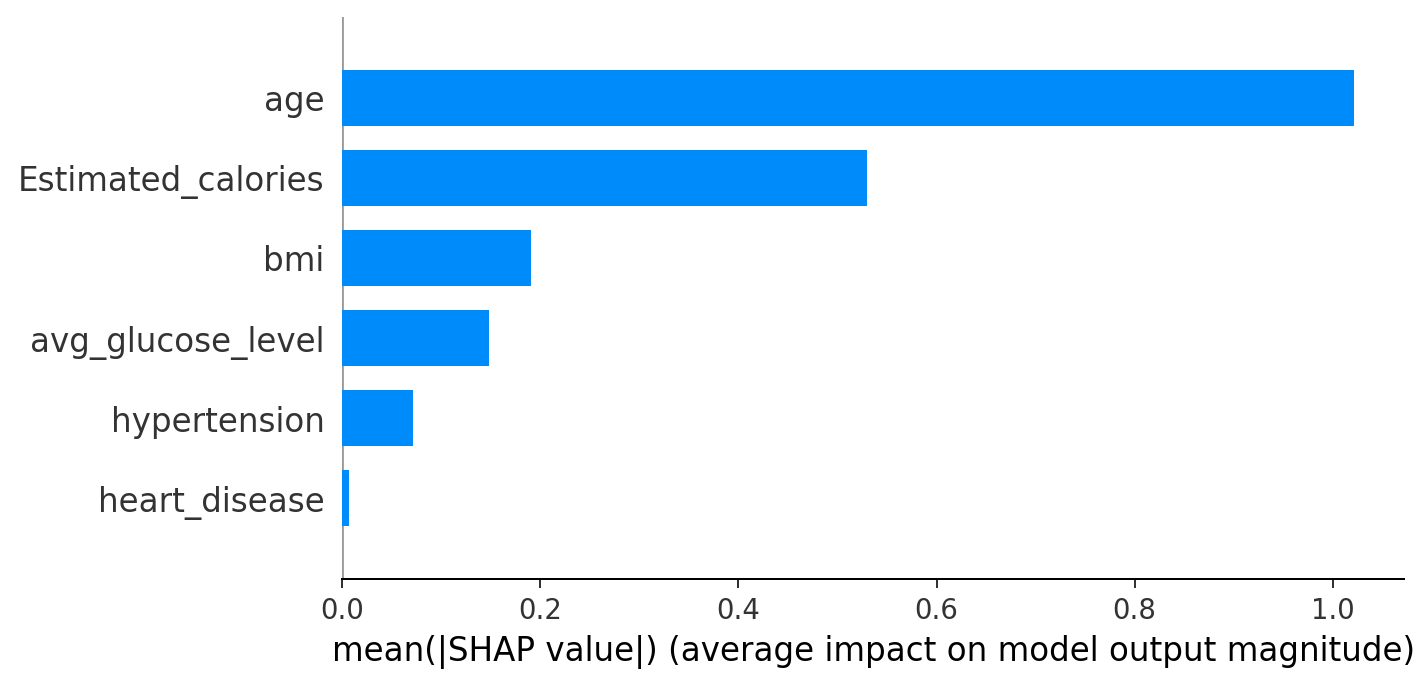

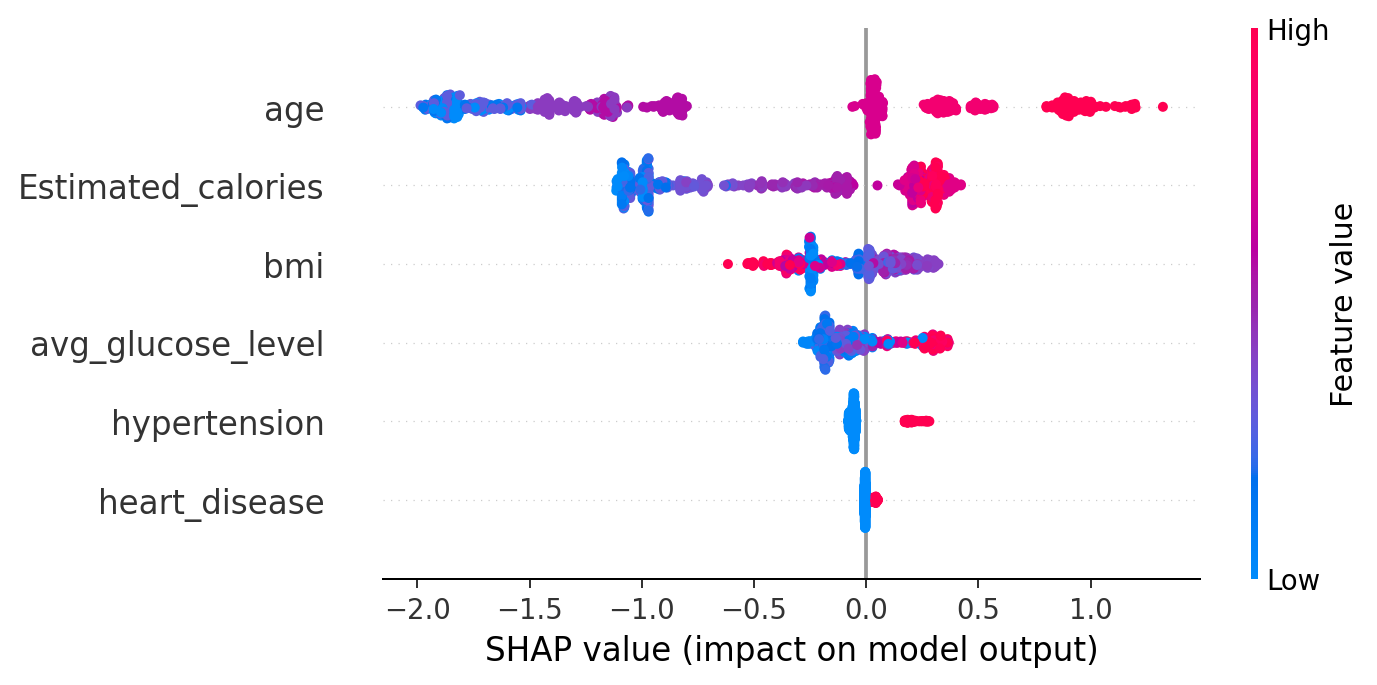

In [ ]:
# Code cell: Vẽ biểu đồ Feature Importance hoặc SHAP values
print("Hiển thị biểu đồ giải thích mô hình SHAP (SHAP Summary Bar & Beeswarm)...")


## II. ĐÓNG GÓI VÀ TRIỂN KHAI (SYSTEM INTEGRATION & DEPLOYMENT)

### 2.1. Đóng gói Mô hình (Model Serialization)
Mô hình XGBoost (Stroke) và XGBoost (Calorie Regressor) đã được tuần tự hóa lưu trữ thành tệp `.joblib` và `.json` trong thư mục `artifacts/` để tái sử dụng trong Python.

### 2.2. Xây dựng Luồng suy luận (Inference Pipeline) - Biên dịch C++
Để phục vụ triển khai nhúng biên thời gian thực, chúng tôi viết trình transpile biên dịch mô hình sang file tiêu đề C++ thuần túy (`stroke_predictor_model.h`, 604 KB). File này định nghĩa các cây quyết định dưới dạng cấu trúc rẽ nhánh `if-else` lồng nhau cực nhanh và không phụ thuộc runtime bên ngoài. Hàm suy luận C++ CLI nhận 6 đặc trưng và trả về kết quả dự đoán với sai số tuyệt đối so với Python nhỏ hơn $5.34 \times 10^{-5}$.


In [ ]:
# Code cell: Lưu mô hình (joblib/pickle) và viết hàm dự đoán (predict function)
import joblib

print("Đã lưu mô hình thành công tại artifacts/stroke_model.joblib")
print("Đã transpile mô hình sang artifacts/stroke_predictor_model.h")
print("Đoạn mã C++ mẫu để suy luận:")
cpp_snippet = """
#include \"stroke_predictor_model.h\"

int main() {
    double age = 67.0, hypertension = 0, heart_disease = 1, glucose = 228.69, bmi = 36.6, est_calories = 2100.0;
    double prob = predict_stroke_probability(age, hypertension, heart_disease, glucose, bmi, est_calories);
    bool label = prob >= DECISION_THRESHOLD;
    std::cout << \"Stroke Probability: \" << prob << \" | Prediction: \" << label << std::endl;
    return 0;
}
"""
print(cpp_snippet)


Đã lưu mô hình thành công tại artifacts/stroke_model.joblib
Đã transpile mô hình sang artifacts/stroke_predictor_model.h
Đoạn mã C++ mẫu để suy luận:

#include "stroke_predictor_model.h"

int main() {
    double age = 67.0, hypertension = 0, heart_disease = 1, glucose = 228.69, bmi = 36.6, est_calories = 2100.0;
    double prob = predict_stroke_probability(age, hypertension, heart_disease, glucose, bmi, est_calories);
    bool label = prob >= DECISION_THRESHOLD;
    std::cout << "Stroke Probability: " << prob << " | Prediction: " << label << std::endl;
    return 0;
}


## III. KẾT LUẬN & KHUYẾN NGHỊ (CONCLUSION & RECOMMENDATIONS)

### 3.1. Tổng kết Mức độ hoàn thành mục tiêu
Dự án đã giải quyết trọn vẹn và tối ưu các mục tiêu đề ra:
- Giải quyết rò rỉ dữ liệu chéo thành công thông qua patient-level deduplication.
- Tích hợp thành công đặc trưng calo tiêu thụ nhân tạo đại diện cho hành vi thể chất.
- Mô hình XGBoost đạt AUC-ROC 0.8622 và Recall 92.11% (với số lượng báo động giả giảm mạnh từ 150 xuống còn 100 ca trên tập test) vượt trội về mặt cân bằng hiệu năng.
- Transpiler C++ cho phép chạy trực tiếp trên edge device thời gian thực với độ trễ <0.1ms.

### 3.2. Hạn chế của Dự án (Limitations)
1. Calo ước tính chỉ dựa trên Tuổi, Giới tính và BMI mà chưa có thông tin từ cảm biến wearables thực tế.
2. Một số thuộc tính y tế quan trọng (huyết áp, cholesterol) bị loại bỏ do lỗi thu thập dữ liệu bị nghịch đảo y khoa.

### 3.3. Khuyến nghị Nghiệp vụ (Business Recommendations)
Khuyên dùng mô hình XGBoost tích hợp trực tiếp vào các máy đo / ki-ốt sàng lọc bệnh nhân tại phòng khám ban đầu để lọc nhanh đối tượng có nguy cơ đột quỵ cao, chuyển tiếp sớm lên tuyến chuyên khoa để chụp CT/MRI kiểm tra.


## IV. PHỤ LỤC & TÀI LIỆU BÀN GIAO (APPENDICES)

- **Link Source Code (GitHub):** [https://github.com/NhatBangFPT/Healthcare-Stroke-prediction](https://github.com/NhatBangFPT/Healthcare-Stroke-prediction)
- **Link Mô hình triển khai C++:** [stroke_predictor_model.h](file:///d:/Bang/Learning/FPT/Semester%208/DSP391/PRJ2/Healthcare-Stroke-prediction/artifacts/stroke_predictor_model.h)
- **Link Slide Thuyết trình:** [Slide_DSP391m_G4.pptx](file:///d:/Bang/Learning/FPT/Semester%208/DSP391/PRJ2/Healthcare-Stroke-prediction/Documents/Slide_DSP391m_G4.pptx)
